# Notebook 01: Exploratory and QC

## Load and Process the Two Timepoint Files (24h and 96h)

- Load the 24h and 96h counts files separately
- Build metadata for each timepoint by parsing sample IDs from the count matrix column names
- Save each timepoint's counts and metadata as separate processed files

Note: 24h and 96h are kept as separate files throughout this project, rather than merged, since they were sequenced with different library preparation protocols (paired-end stranded vs. single-end unstranded). Combining them into one file or one model could conflate a real biological timepoint effect with this technical difference. This was confirmed directly from the original paper's own analysis code, which processed each timepoint independently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hspc_response.io import load_config, resolve_path, load_counts_matrix, build_metadata
from hspc_response.plotting import plot_library_size_qc, plot_cpm_distribution, plot_pca
from hspc_response.qc import filter_low_gene_expression
from hspc_response.differential_expression import build_dds, compute_pca

In [2]:
config = load_config()

# Load the raw counts file for each timepoint 
counts_24h = load_counts_matrix(resolve_path(config["paths"]["counts_24h"]))
counts_96h = load_counts_matrix(resolve_path(config["paths"]["counts_96h"]))

# Create metadata file for each timepoint 
metadata_24h = build_metadata(counts_24h)
metadata_96h = build_metadata(counts_96h)

# Save counts file for each timepoint to leave the raw files alone
counts_24h.to_csv(resolve_path(config["paths"]["counts_24h_processed"]))
counts_96h.to_csv(resolve_path(config["paths"]["counts_96h_processed"]))

# Save metadata files
metadata_24h.to_csv(resolve_path(config["paths"]["metadata_24h"]), index=False)
metadata_96h.to_csv(resolve_path(config["paths"]["metadata_96h"]), index=False)


In [3]:
# Check metadata file: + metadata_96h
metadata_96h

,sample_id,well_code,condition,timepoint
0,BAM:N1:GE_96h,N1,GE,96h
1,BAM:N2:GE_ANAK_96h,N2,GE_ANAK,96h
2,BAM:N3:GE_96h,N3,GE,96h
3,BAM:N4:GE_ANAK_96h,N4,GE_ANAK,96h
4,BAM:N5:GE_96h,N5,GE,96h
5,BAM:N6:GE_ANAK_96h,N6,GE_ANAK,96h
6,BAM:N7:RNP_NEG_96h,N7,RNP_NEG,96h
7,BAM:N8:RNP_NEG_96h,N8,RNP_NEG,96h
8,BAM:N9:RNP_NEG_96h,N9,RNP_NEG,96h


## Check Library Size

Checks total read counts per sample, separately for each timepoint since they used different sequencing protocols and shouldn't be compared directly. Flags any sample with an unusually high or low library size that might need further investigation.

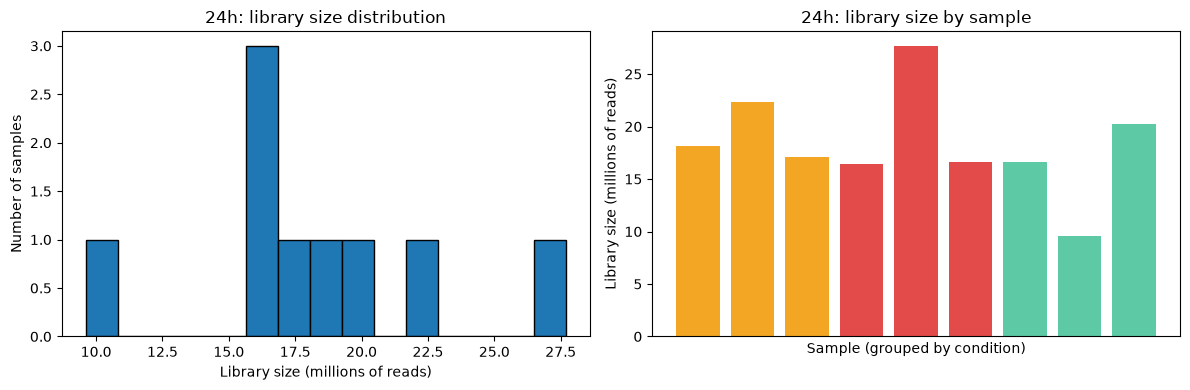

Outlier samples (>3 SD from mean): 0


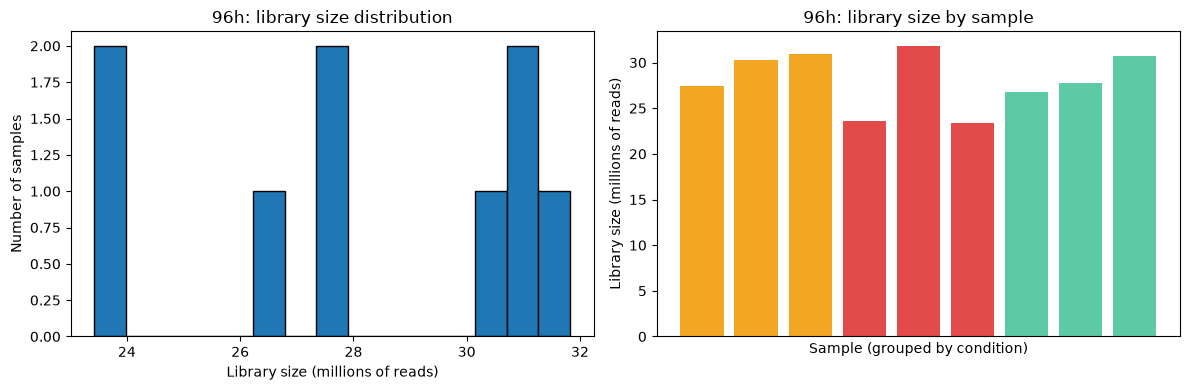

Outlier samples (>3 SD from mean): 0


In [4]:

# Color scheme used to visually distinguish conditions across plots
color_map = {"RNP_NEG": "#5DCAA5", "GE": "#F2A623", "GE_ANAK": "#E24B4A"}

# Check library size distribution and flag any outlier samples at 24h
lib_sizes_24h, outliers_24h = plot_library_size_qc(
    counts_24h, metadata_24h,
    group_col="condition", sample_id_col="sample_id",
    color_map=color_map, title_prefix="24h",
    save_path=resolve_path("results/figures/library_size_qc_24h.png"),
)
# Check library size distribution and flag any outlier samples at 96h
lib_sizes_96h, outliers_96h = plot_library_size_qc(
    counts_96h, metadata_96h,
    group_col="condition", sample_id_col="sample_id",
    color_map=color_map, title_prefix="96h",
    save_path=resolve_path("results/figures/library_size_qc_96h.png"),
)

## Filter low-count genes

Genes with very low counts across all samples provide little statistical power and add noise to downstream dispersion estimation. The original paper's methods describe no manual low-count filtering step before DESeq2. As additional QC, a CPM-based filter (min_count=10) is applied here, verified against the expression distribution for each timepoint below.

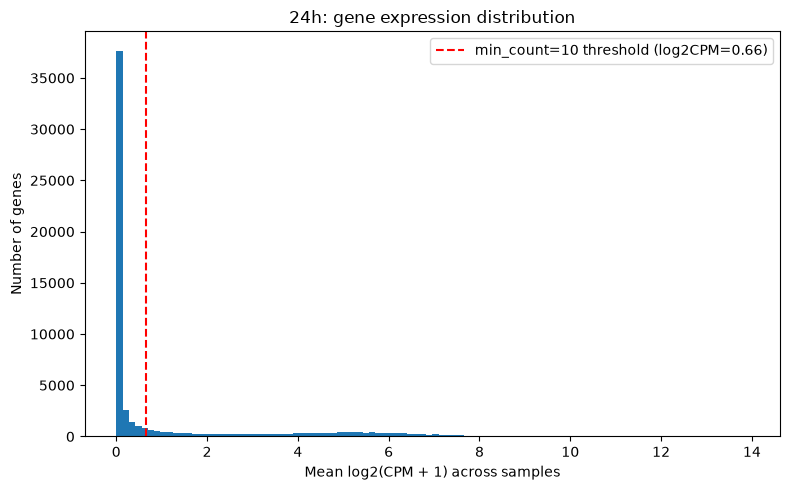

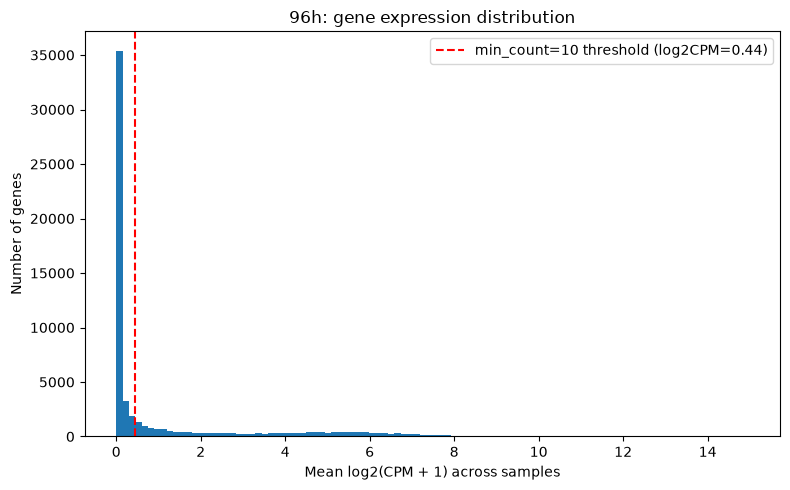

In [5]:
# Visualize gene expression distribution and where the min_count=10 threshold falls, separately for each timepoint (library sizes differ between them)
plot_cpm_distribution(counts_24h, min_count=10, title_prefix="24h",
                       save_path=resolve_path("results/figures/cpm_distribution_24h.png"))
plot_cpm_distribution(counts_96h, min_count=10, title_prefix="96h",
                       save_path=resolve_path("results/figures/cpm_distribution_96h.png"))

The threshold falls just past the dominant unexpressed-gene peak at both timepoints, supporting `min_count=10` as a reasonable cutoff. This filter is now applied. 

In [6]:
# Apply CPM-based low-count filter (min_count=10) separately per timepoint,
counts_24h_filtered, summary_24h = filter_low_gene_expression(counts_24h, metadata_24h, group_col="condition")
counts_96h_filtered, summary_96h = filter_low_gene_expression(counts_96h, metadata_96h, group_col="condition")

# Check how many genes were kept at each timepoint
print("24h:", summary_24h)
print("96h:", summary_96h)

# Save the filtered counts files for both 24h and 96h
config = load_config()

counts_24h_filtered.to_csv(resolve_path(config["paths"]["counts_24h_filtered"]))
counts_96h_filtered.to_csv(resolve_path(config["paths"]["counts_96h_filtered"]))


24h: {'genes_before_filtering': 59653, 'genes_after_filtering': 16907, 'min_count': 10, 'smallest_group_size': np.int64(3)}
96h: {'genes_before_filtering': 59653, 'genes_after_filtering': 20536, 'min_count': 10, 'smallest_group_size': np.int64(3)}


## PCA
PCA is run on variance-stabilized counts, separately for each timepoint, to check whether samples separate by condition (RNP_NEG / GE / GE_ANAK). This confirms that condition is a real, detectable source of variance before proceeding to formal DE testing. Each timepoint is analyzed independently, consistent with fitting separate per-timepoint models.

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.89 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 2.02 seconds.

Fitting LFCs...
... done in 1.14 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.82 seconds.



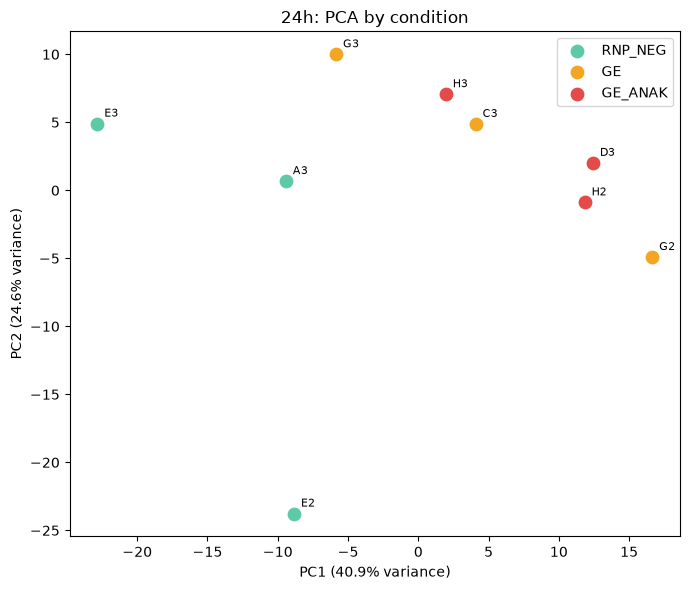

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.22 seconds.

Fitting dispersion trend curve...
... done in 0.30 seconds.

Fitting MAP dispersions...
... done in 2.53 seconds.

Fitting LFCs...
... done in 1.66 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.19 seconds.



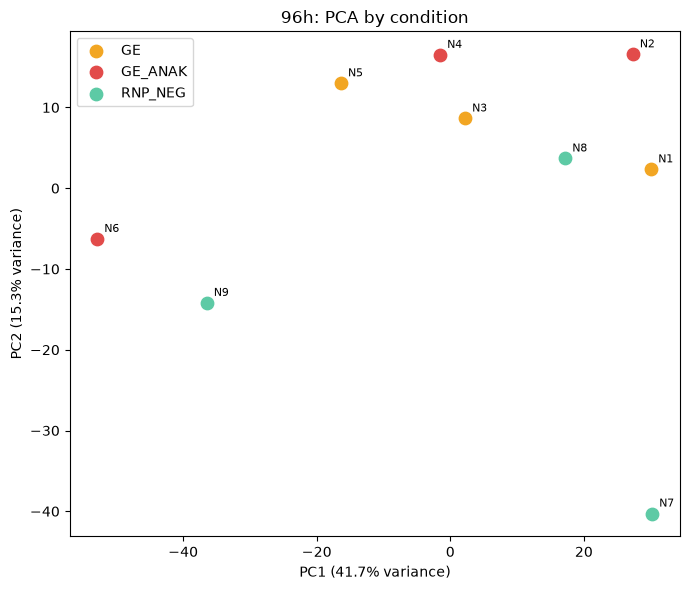

In [7]:
# Build a dds object and run PCA for 24h
dds_24h_qc = build_dds(
    counts_24h_filtered, metadata_24h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)
coords_24h, pca_24h = compute_pca(dds_24h_qc)

# Plot PCA colored by condition, labeled by well code, for 24h
plot_pca(
    coords_24h, pca_24h, metadata_24h,
    group_col="condition", sample_id_col="sample_id",
    color_map=color_map, sample_ids_ordered=counts_24h_filtered.columns.tolist(),
    title_prefix="24h", save_path=resolve_path("results/figures/pca_24h_labeled.png"),
)

# Build a dds object and run PCA for 96h
dds_96h_qc = build_dds(
    counts_96h_filtered, metadata_96h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)
coords_96h, pca_96h = compute_pca(dds_96h_qc)

# Plot PCA colored by condition, labeled by well code, for 96h
plot_pca(
    coords_96h, pca_96h, metadata_96h,
    group_col="condition", sample_id_col="sample_id",
    color_map=color_map, sample_ids_ordered=counts_96h_filtered.columns.tolist(),
    title_prefix="96h", save_path=resolve_path("results/figures/pca_96h_labeled.png"),
)

## PCA Summary: 

PCA revealed one visually distinct outlier at each timepoint: E2 (RNP_NEG, 24h) and N7 (RNP_NEG, 96h). 

- **E2 (24h)**: library size of 9.6M reads, substantially lower than every other 24h sample (next-lowest: 16.4M). This is a plausible explanation for its PCA separation. At markedly lower sequencing depth, gene expression estimates are noisier, which commonly manifests as an outlier position in PCA space.

- **N7 (96h)**: library size of 26.7M reads, within the normal range for 96h samples (23.4M to 31.8M). Its PCA separation has no library-size explanation based on the diagnostics run here. The cause is unknown. It could be genuine biological variability in this replicate, an unmeasured technical factor, or noise inherent to the sample size.

### Decision: 
Both samples are retained in the analysis. Excluding either would reduce its condition/timepoint group to n=2, which would compromise statistical power more than the outlier itself is likely to distort results. This is documented as a known limitation moving forward. 

## Notebook 01 summary

- Loaded and parsed 24h (GSE244247) and 96h (GSE244248) featureCounts matrices, extracting condition/timepoint metadata directly from sample column names.

- Confirmed no duplicate gene symbols in either file.

- In the original paper's methods, no manual low-count gene filter is described 
    - **Applied own CPM-based filter (min_count=10, verified visually against each timepoint's expression distribution) as extra QC rigor beyond the paper's own approach.**

- Library size QC showed no extreme outliers by an automated 3-SD threshold at either timepoint, though the raw range varied meaningfully (24h: 9.6M-27.7M; 96h: 23.4M-31.8M reads). This is consistent with the two timepoints using different library preparation protocols (paired-end stranded at 24h vs. single-end unstranded at 96h). A difference maintained throughout this analysis by fitting separate models per timepoint rather than one combined model, but also noting as a limitation on how results should be interpreted. 

- PCA identified one outlier sample per timepoint (E2 at 24h, N7 at 96h); E2's outlier status is explained by its low library size, N7's is not. Both are retained for downstream analysis. 